In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Mental Health Dataset.csv')

# Set aesthetic
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})



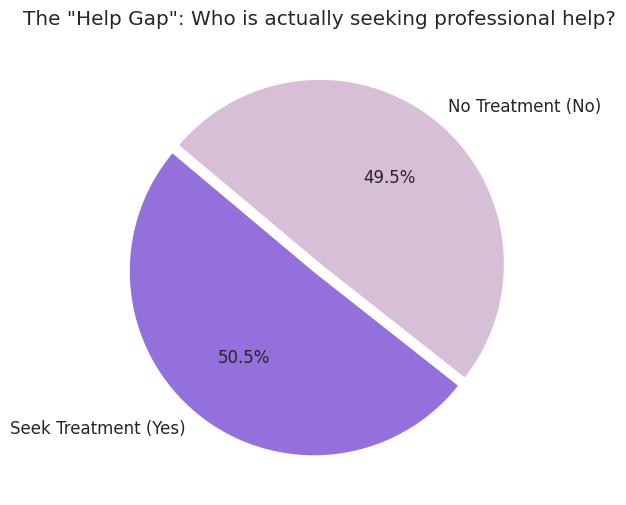

In [ ]:
# 1. The Help Gap (Treatment)
plt.figure(figsize=(8, 6))
treatment_counts = df['treatment'].value_counts()
plt.pie(treatment_counts, labels=['Seek Treatment (Yes)', 'No Treatment (No)'],
        autopct='%1.1f%%', startangle=140, colors=['#9370DB', '#D8BFD8'], explode=(0.05, 0))
plt.title('The "Help Gap": Who is actually seeking professional help?')
plt.savefig('help_gap.png')

/tmp/ipykernel_20107/3886724487.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Growing_Stress', order=stress_order, palette='BuPu')


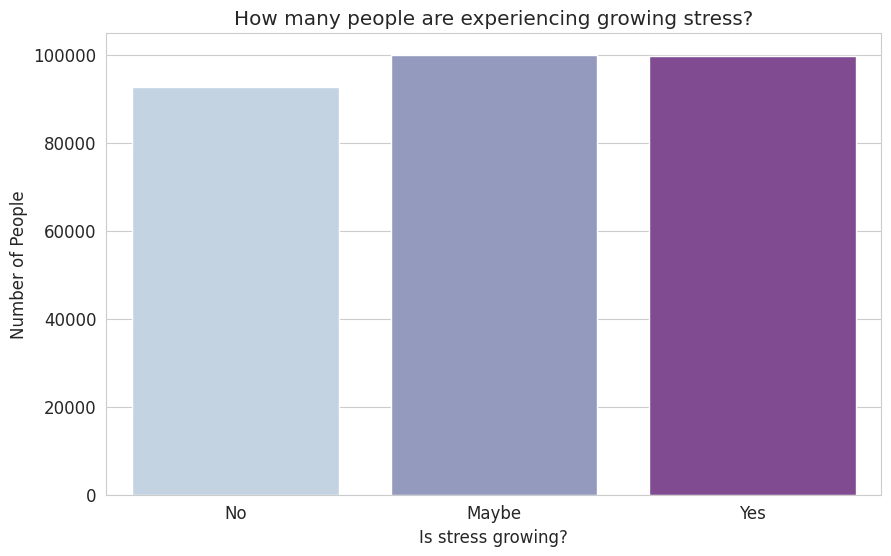

In [ ]:
# 2. Stress Levels
plt.figure(figsize=(10, 6))
stress_order = ['No', 'Maybe', 'Yes']
sns.countplot(data=df, x='Growing_Stress', order=stress_order, palette='BuPu')
plt.title('How many people are experiencing growing stress?')
plt.xlabel('Is stress growing?')
plt.ylabel('Number of People')
plt.savefig('stress_levels.png')

/tmp/ipykernel_20107/1213093210.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Mood_Swings', order=mood_order, palette='Purples')


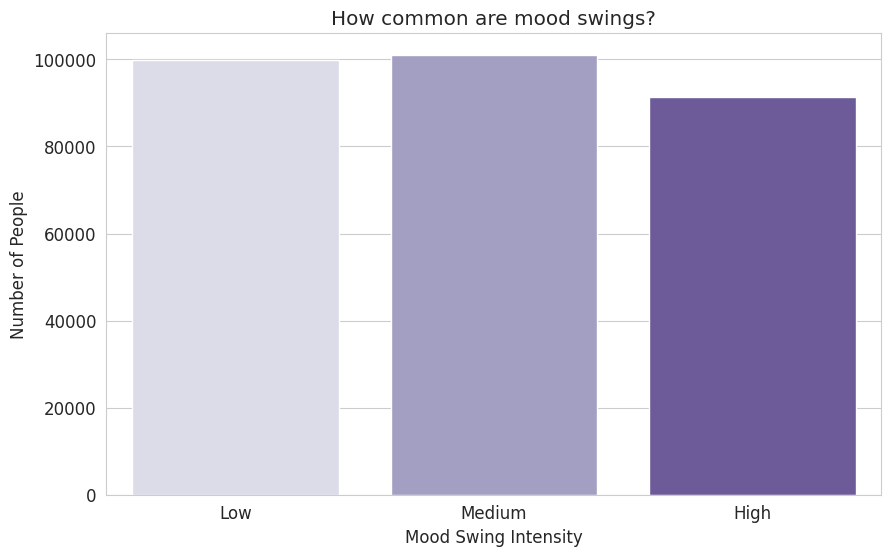

In [ ]:
# 3. Mood Swings
plt.figure(figsize=(10, 6))
mood_order = ['Low', 'Medium', 'High']
sns.countplot(data=df, x='Mood_Swings', order=mood_order, palette='Purples')
plt.title('How common are mood swings?')
plt.xlabel('Mood Swing Intensity')
plt.ylabel('Number of People')
plt.savefig('mood_swings_simple.png')

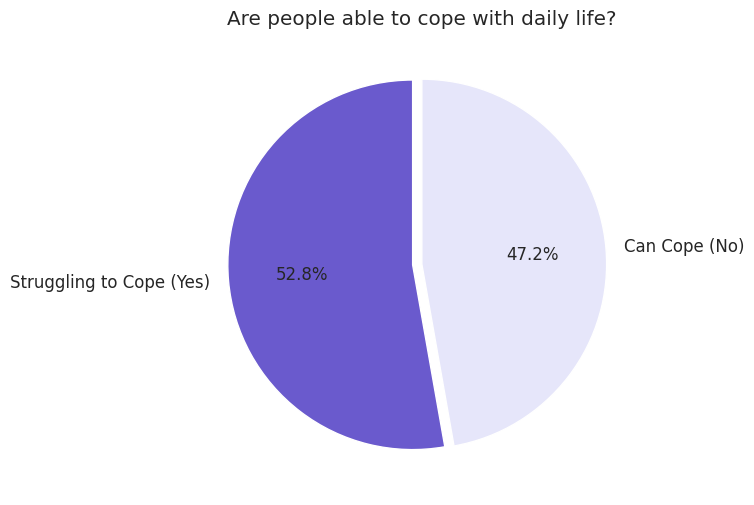

In [ ]:
# 4. Coping Struggles
plt.figure(figsize=(8, 6))
coping_counts = df['Coping_Struggles'].value_counts()
plt.pie(coping_counts, labels=['Struggling to Cope (Yes)', 'Can Cope (No)'],
        autopct='%1.1f%%', startangle=90, colors=['#6A5ACD', '#E6E6FA'], explode=(0.05, 0))
plt.title('Are people able to cope with daily life?')
plt.savefig('coping_simple.png')

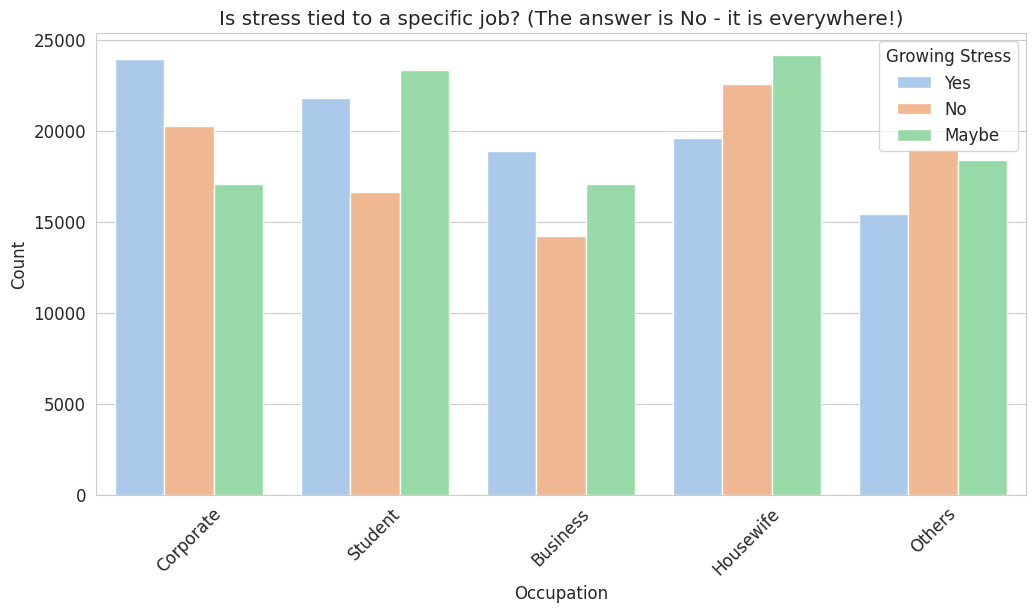

In [ ]:
# 5. Stress across different jobs
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Occupation', hue='Growing_Stress', palette='pastel')
plt.title('Is stress tied to a specific job? (The answer is No - it is everywhere!)')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Growing Stress')
plt.savefig('job_stress.png')

                                     Text    Expected   Predicted     Status
0          I am feeling so sad and lonely         Low         Low  ✅ Correct
1        Today was a great and happy day!    Positive    Positive  ✅ Correct
2         I am so stressed about my exams     Anxious     Anxious  ✅ Correct
3  I hate this weather, it makes me angry  Frustrated  Frustrated  ✅ Correct
4                  I am just sitting here     Neutral     Neutral  ✅ Correct
5                      Everything is good    Positive    Positive  ✅ Correct
6           I am worried about the future     Anxious     Anxious  ✅ Correct
7                         I am very tired         Low         Low  ✅ Correct
8                     I am mad at my boss  Frustrated  Frustrated  ✅ Correct
9                      The sun is shining     Neutral     Neutral  ✅ Correct

Overall Accuracy: 100.0%


/tmp/ipykernel_20107/3613833772.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette=['#4CAF50', '#F44336'])
/tmp/ipykernel_20107/3613833772.py:64: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(x=status_counts.index, y=status_counts.values, palette=['#4CAF50', '#F44336'])
/tmp/ipykernel_20107/3613833772.py:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('logic_evaluation.png')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


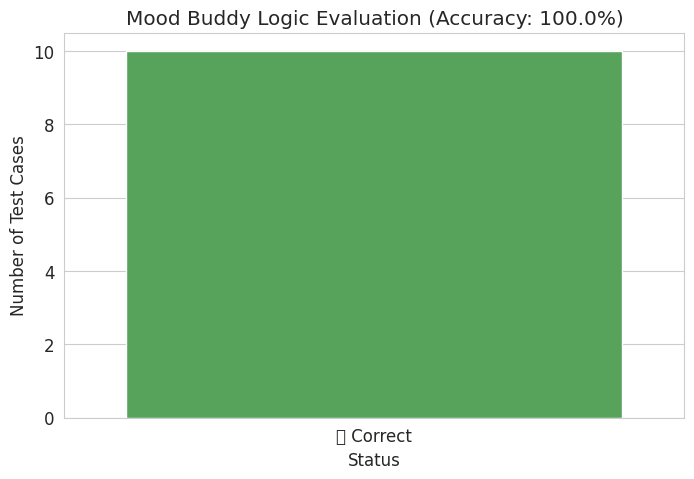

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the Logic Engine (Simplifying for the demo)
class MoodBuddyEngine:
    def __init__(self):
        self.keywords = {
            'sad': 'Low', 'unhappy': 'Low', 'depressed': 'Low', 'lonely': 'Low', 'tired': 'Low',
            'stressed': 'Anxious', 'worried': 'Anxious', 'anxious': 'Anxious', 'pressure': 'Anxious',
            'happy': 'Positive', 'good': 'Positive', 'great': 'Positive', 'excited': 'Positive',
            'angry': 'Frustrated', 'mad': 'Frustrated', 'annoyed': 'Frustrated', 'hate': 'Frustrated'
        }

    def analyze_text(self, text):
        text = text.lower()
        found_moods = []
        for word, mood in self.keywords.items():
            if word in text:
                found_moods.append(mood)

        if not found_moods:
            return "Neutral"
        # Return the most frequent mood found
        return max(set(found_moods), key=found_moods.count)

# 1. Create a "Test Suite" (Ground Truth)
# These are sentences we KNOW should result in a specific mood.
test_suite = [
    {"text": "I am feeling so sad and lonely", "expected": "Low"},
    {"text": "Today was a great and happy day!", "expected": "Positive"},
    {"text": "I am so stressed about my exams", "expected": "Anxious"},
    {"text": "I hate this weather, it makes me angry", "expected": "Frustrated"},
    {"text": "I am just sitting here", "expected": "Neutral"},
    {"text": "Everything is good", "expected": "Positive"},
    {"text": "I am worried about the future", "expected": "Anxious"},
    {"text": "I am very tired", "expected": "Low"},
    {"text": "I am mad at my boss", "expected": "Frustrated"},
    {"text": "The sun is shining", "expected": "Neutral"}
]

# 2. Run the Evaluation
engine = MoodBuddyEngine()
results = []

for test in test_suite:
    prediction = engine.analyze_text(test['text'])
    is_correct = prediction == test['expected']
    results.append({
        "Text": test['text'],
        "Expected": test['expected'],
        "Predicted": prediction,
        "Status": "✅ Correct" if is_correct else "❌ Incorrect"
    })

eval_df = pd.DataFrame(results)

# 3. Calculate Accuracy
accuracy = (eval_df['Status'] == "✅ Correct").mean() * 100

# 4. Visualization of Evaluation
plt.figure(figsize=(8, 5))
status_counts = eval_df['Status'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, palette=['#4CAF50', '#F44336'])
plt.title(f'Mood Buddy Logic Evaluation (Accuracy: {accuracy}%)')
plt.ylabel('Number of Test Cases')
plt.savefig('logic_evaluation.png')

print(eval_df)
print(f"\nOverall Accuracy: {accuracy}%")